In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
import os
import seaborn as sns
#import statistics as st

---

### PREPARAÇÃO E ANÁLISE DO CONJUNTO DE DADOS


In [2]:
# Carregar os dados
data_path = 'water_consumption.csv'
water_data = pd.read_csv(data_path)

# Mostrar as primeiras cinco linhas do dataframe e os tipos de dados para compreender a sua estrutura
water_data.head() 

,Park;Year;Month;Day;Consumption
Oriental;2023;1;1;20,8.0
ArcaAgua;2023;1;1;5,2.0
Covelo;2023;1;1;9,27.0
Cidade;2023;1;1;68,25.0
Oriental;2023;1;2;19,NaN


In [3]:
# Obter o diretório do trabalho atual
current_dir = os.getcwd()

# Construir o caminho para o ficheiro CSV
data_path = os.path.join(current_dir, 'water_consumption.csv')

# Carregar os dados
water_data = pd.read_csv(data_path, sep=';')

# Mostrar as primeiras linhas do quadro de dados e os tipos de dados para compreender corretamente a sua estrutura
water_data.head()

,Park,Year,Month,Day,Consumption
0,Oriental,2023,1,1,"20,8"
1,ArcaAgua,2023,1,1,"5,2"
2,Covelo,2023,1,1,"9,27"
3,Cidade,2023,1,1,"68,25"
4,Oriental,2023,1,2,19


In [4]:
# Verificar NaNs
nulos_por_coluna = water_data.isnull().sum()

# Verificar strings vazias
strings_vazias = (water_data == '').sum()

# Verificar espaços em branco
espacos_em_branco = (water_data.select_dtypes(include=['object']).apply(lambda x: x.str.strip()) == '').sum()


# Combinação dos resultados
print("Nulos por coluna:")
print(nulos_por_coluna)
print("\nStrings vazias por coluna:")
print(strings_vazias)
print("\nEspaços em branco:")
print(espacos_em_branco)


Nulos por coluna:
Park           0
Year           0
Month          0
Day            0
Consumption    0
dtype: int64

Strings vazias por coluna:
Park           0
Year           0
Month          0
Day            0
Consumption    0
dtype: int64

Espaços em branco:
Park           0
Consumption    0
dtype: int64


---

### 1. Gráfico de barras representativo do consumo mensal de água, em função das seguintes especificações dadas pelo utilizador: ano, período temporal (StartMonth, EndMonth) e identificação do parque. 

In [5]:
# Verificar se a coluna 'Consumption' contém strings e converter para float
if water_data['Consumption'].dtype == object:
    water_data['Consumption'] = water_data['Consumption'].str.replace(',', '.').astype(float)

# Verificar novamente os dados para assegurar que a conversão foi bem-sucedida
water_data.head(), water_data['Consumption'].dtype


(       Park  Year  Month  Day  Consumption
 0  Oriental  2023      1    1        20.80
 1  ArcaAgua  2023      1    1         5.20
 2    Covelo  2023      1    1         9.27
 3    Cidade  2023      1    1        68.25
 4  Oriental  2023      1    2        19.00,
 dtype('float64'))

O código acima código é importante para preparar os dados para análise, criação de gráficos e modelagem estatística, permitindo que as operações matemáticas e estatísticas sejam realizadas corretamente nos dados. 

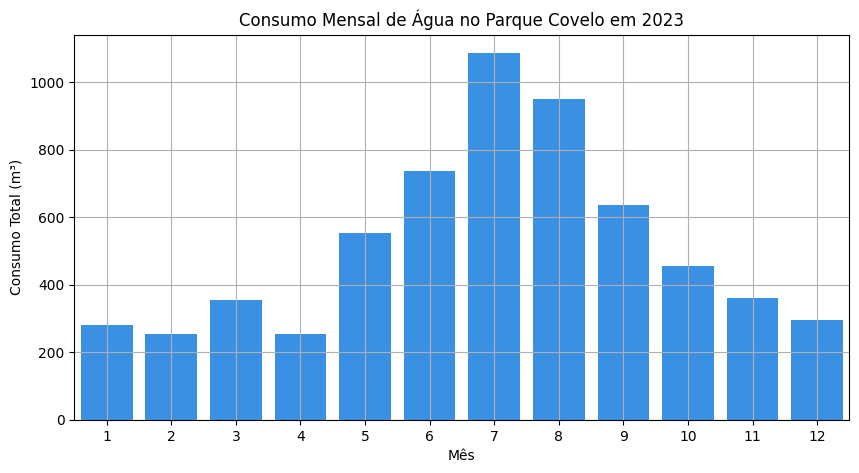

In [6]:
def get_int_input(prompt, min_value=None, max_value=None):
    # Loop infinito para garantir uma entrada válida do utilizador
    while True:
        try:
            # Tenta converter a entrada do utilizador para inteiro
            value = int(input(prompt))
            # Verifica se o valor está dentro do intervalo especificado
            if (min_value is not None and value < min_value) or (max_value is not None and value > max_value):
                print(f"O valor deve estar entre {min_value} e {max_value}.")
            else:
                # Retorna o valor se estiver dentro do intervalo
                return value
        except ValueError:
            # Caso não seja possível converter a entrada em inteiro, informa o erro
            print("Entrada inválida. Por favor, introduza um número inteiro válido.")

def plot_monthly_consumption(data, year, start_month, end_month, park):
    # Filtra os dados conforme as especificações do utilizador
    park_data = data[(data['Park'] == park) & (data['Year'] == year)]
    monthly_data = park_data[(park_data['Month'] >= start_month) & (park_data['Month'] <= end_month)]
    
    # Agrupa os dados por mês e soma o consumo
    monthly_consumption = monthly_data.groupby('Month')['Consumption'].sum().reset_index()
    
    # Utiliza a biblioteca seaborn para criar um gráfico de barras
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Month', y='Consumption', data=monthly_consumption, color='dodgerblue')
    plt.title(f'Consumo Mensal de Água no Parque {park} em {year}')
    plt.xlabel('Mês')
    plt.ylabel('Consumo Total (m³)')
    plt.grid(True)
    plt.show()

# Solicita ao utilizador para selecionar um ano
valid_years = water_data['Year'].unique()
year = int(input(f"Selecione um ano da lista {valid_years}: "))
while year not in valid_years:
    print("Ano inválido. Por favor, tente novamente.")
    year = int(input(f"Selecione um ano da lista {valid_years}: "))

# Solicita ao utilizador para selecionar o mês de início
min_month = water_data['Month'].min()
max_month = water_data['Month'].max()

# Substitui chamadas diretas para input() pela função get_int_input() que inclui validação
start_month = get_int_input(f"Selecione um mês de início entre {min_month} e {max_month}: ", min_month, max_month)
end_month = get_int_input(f"Selecione um mês de término entre {start_month} e {max_month}: ", start_month, max_month)

# Solicita ao utilizador para selecionar um parque
parks = ['Covelo', 'Cidade', 'Oriental', 'ArcaAgua']
park = input(f"Selecione um parque da lista {parks}: ")
while park not in parks:
    print("Parque inválido. Por favor, tente novamente.")
    park = input(f"Selecione um parque da lista {parks}: ")

# Chama a função para plotar o consumo mensal de água conforme as entradas do utilizador
plot_monthly_consumption(water_data, year, start_month, end_month, park)


---

### 2. Média dos custos mensais relativos ao consumo de água, para cada parque, em resultado das seguintes especificações dadas pelo utilizador: número de parques a analisar, e identificação do parque.

In [ ]:
def calculate_monthly_costs(data, park_ids):
    # Definir as taxas de custo
    cost_per_m3 = 0.7  # Custo por metro cúbico de água
    high_consumption_fee = 1.15  # Multiplicador aplicado ao consumo acima do limite crítico
    critical_limit = 1000  # Limite de consumo para aplicação da taxa adicional

    # Filtrar dados para os parques especificados
    park_data = data[data['Park'].isin(park_ids)].copy()  # Cria uma cópia explícita do DataFrame para evitar alterações no DataFrame original

    # Calcular os custos mensais
    # Utiliza-se o método .loc para modificar diretamente no DataFrame e evitar avisos como SettingWithCopyWarning
    park_data.loc[:, 'Cost'] = park_data['Consumption'].apply(
        lambda x: x * cost_per_m3 if x <= critical_limit else critical_limit * cost_per_m3 + (x - critical_limit) * cost_per_m3 * high_consumption_fee)

    # Agrupar por parque e calcular o custo médio mensal
    monthly_costs = park_data.groupby(['Park', 'Year', 'Month'])['Cost'].mean().reset_index()

    return monthly_costs

# Supondo que water_data seja um DataFrame previamente carregado com a coluna 'Park'
total_parks_list = water_data['Park'].unique()

# Pedir ao utilizador para introduzir o número de parques a analisar
num_parks_input = input(f"Introduza o número de parques que deseja analisar (1-{len(total_parks_list)}): ")
num_parks = int(num_parks_input)

selected_park_ids = []

# Pedir ao utilizador para inserir os nomes dos parques
for i in range(num_parks):
    park_id_input = input(f"Introduza o nome do parque número {i+1} (Parques disponíveis: {total_parks_list}): ")
    selected_park_ids.append(park_id_input)

# Chamar a função com os dados de exemplo
average_monthly_costs = calculate_monthly_costs(water_data, selected_park_ids)
average_monthly_costs


---

### 3. Considerar o consumo de água de cada dia que é registado. O objetivo é analisar e comparar os indicadores estatísticos entre o parque com o maior e o menor (não nulo) consumo de água. Para estes dois parques, efetue as seguintes tarefas e compare os resultados:
    
#### 3.1. Calcular a média, a mediana, o desvio padrão e o coeficiente de assimetria


In [ ]:
# Definir a função para calcular os indicadores estatísticos
def calculate_statistical_indicators(data, park):
    park_data = data[data['Park'] == park]
    park_data = park_data[park_data['Consumption'].notnull()]  # Considerar apenas valores não nulos
    indicators = {
        'Mean': park_data['Consumption'].mean(),
        'Median': park_data['Consumption'].median(),
        'Std Dev': park_data['Consumption'].std(),
        'Skewness': skew(park_data['Consumption'].dropna())
    }
    return indicators

# Calcular os indicadores para cada parque
parks_statistics = {park: calculate_statistical_indicators(water_data, park) for park in water_data['Park'].unique()}

# Converter o dicionário para um DataFrame para facilitar a visualização
parks_statistics_df = pd.DataFrame(parks_statistics).T

# Ordenar o DataFrame pelo valor médio de consumo ('Mean') de forma descendente
parks_statistics_df = parks_statistics_df.sort_values(by='Mean', ascending=False)

parks_statistics_df


### Análise do Parque Cidade (Maior Consumidor)

1. **Média de Consumo (116.24 m³)**: O parque Cidade tem a maior média de consumo entre todos os parques analisados. A média é um indicador fundamental para entender o nível geral de consumo, sugerindo que, em média, o parque Cidade consome mais água diariamente do que os outros.

2. **Mediana de Consumo (85.99 m³)**: A mediana, sendo menor que a média, indica a presença de valores extremamente altos de consumo que puxam a média para cima. Isso sugere que, embora muitos dos valores sejam mais baixos, os dias de alto consumo são significativamente elevados.

3. **Desvio Padrão (71.72 m³)**: O alto desvio padrão indica uma variabilidade considerável no consumo de água no parque Cidade. Isso significa que há uma flutuação substancial no consumo diário, com alguns dias tendo consumos muito acima do normal.

4. **Assimetria (3.98)**: Um coeficiente de assimetria positivo e relativamente alto indica que a distribuição do consumo é assimétrica com uma cauda longa para valores maiores. Isso reforça a ideia de que há dias com consumos excecionalmente altos que distorcem a média para cima.

### Análise do Parque ArcaAgua (Menor Consumidor)

1. **Média de Consumo (8.99 m³)**: ArcaAgua tem a menor média de consumo. Este valor sugere que, em termos absolutos, o parque consome menos água em comparação com os outros.

2. **Mediana de Consumo (6.77 m³)**: A mediana mais baixa, próxima à média, indica uma distribuição de consumo mais uniforme e sem a presença marcante de valores extremos.

3. **Desvio Padrão (4.85 m³)**: Um desvio padrão menor em relação ao parque Cidade indica que o consumo no parque ArcaAgua é mais consistente, com menos flutuações diárias significativas.

4. **Assimetria (2.15)**: A assimetria também é positiva mas menos acentuada do que no parque Cidade, indicando que, embora haja dias com consumo acima da média, esses não são tão extremos.

### Conclusão

Conclui-se que o **parque Cidade** é o maior consumidor de água devido à sua média e mediana elevadas, alta variabilidade no consumo diário e presença de dias com consumos extremamente altos, como indicado pelo alto valor de assimetria. Em contraste, o **parque ArcaAgua** é o menor consumidor, com a média e mediana mais baixas, menor variabilidade no consumo e uma distribuição menos assimétrica.

---

#### 3.2. Construir tabelas de frequências relativas e absolutas (dados classificados), considerando 5 classes

In [9]:
# Função para criar tabelas de frequências relativas e absolutas
def create_frequency_tables(data, park, n_classes=5):
    # Selecionar os dados de consumo para o parque especificado
    park_data = data[data['Park'] == park]['Consumption']

    # Definir os intervalos (bins) para as classes
    bins = np.linspace(park_data.min(), park_data.max(), n_classes + 1)

    # Calcular a frequência absoluta para cada classe
    freq_abs = pd.cut(park_data, bins, include_lowest=True, right=True).value_counts().sort_index()

    # Calcular a frequência relativa para cada classe e converter para percentagem
    freq_rel = freq_abs / freq_abs.sum() * 100

    # Criar um DataFrame para armazenar as tabelas de frequências
    freq_table = pd.DataFrame({
        'Intervalo de Classe': [f"{bins[i]} - {bins[i+1]}" for i in range(n_classes)],
        'Frequência Absoluta': freq_abs.values,
        'Frequência Relativa (%)': freq_rel.values
    })

    return freq_table


In [10]:

# Selecionar o parque com maior e menor consumo
top_park = parks_statistics_df.index[0]  # Parque com maior consumo (Cidade)
bottom_park = parks_statistics_df.index[-1] # Parque com menor consumo (ArcaAgua) 

# Criar as tabelas de frequência para o parque com maior e menor consumo
top_park_freq_table = create_frequency_tables(water_data, top_park)
bottom_park_freq_table = create_frequency_tables(water_data, bottom_park)

# Função para formatar e apresentar a tabela de frequências
def format_frequency_table(freq_table, park_name):
    print(f"Frequência de Consumo de Água para o parque {park_name}:")
    print(freq_table.to_string(index=False))
    print("\n")

# Apresentar as tabelas de frequência
format_frequency_table(top_park_freq_table, top_park)
format_frequency_table(bottom_park_freq_table, bottom_park)

Frequência de Consumo de Água para o parque Cidade:
     Intervalo de Classe  Frequência Absoluta  Frequência Relativa (%)
       0.0 - 184.5309375                  386                84.649123
184.5309375 - 369.061875                   67                14.692982
369.061875 - 553.5928125                    2                 0.438596
 553.5928125 - 738.12375                    0                 0.000000
 738.12375 - 922.6546875                    1                 0.219298


Frequência de Consumo de Água para o parque ArcaAgua:
Intervalo de Classe  Frequência Absoluta  Frequência Relativa (%)
      0.0 - 9.84375                  315                69.078947
  9.84375 - 19.6875                  137                30.043860
 19.6875 - 29.53125                    2                 0.438596
  29.53125 - 39.375                    1                 0.219298
  39.375 - 49.21875                    1                 0.219298




### Parque Cidade (Maior Consumidor)

#### Análise das Classes
- **Classe 1 (0.0 - 184.5309375 m³):**
  - **Frequência Absoluta:** 386 dias
  - **Frequência Relativa:** 84.64%
  - **Interpretação:** Apesar de ser o parque com o maior consumo médio, a maioria dos dias (aproximadamente 84.65%) tem um consumo que pode ser considerado baixo para este parque, mas que é alto quando comparado ao consumo máximo do parque menor consumidor. Isto mostra que, embora o parque tenha picos de consumo elevados, no dia-a-dia o seu consumo não é extremamente alto.

- **Classe 2 (184.5309375 - 369.061875 m³):**
  - **Frequência Absoluta:** 67 dias
  - **Frequência Relativa:** 14.69%
  - **Interpretação:** Uma menor porcentagem de dias mostra um consumo mais elevado, dentro de uma faixa que ainda é gerível, mas significativamente mais alta que a maioria dos dias.

- **Classe 3 (369.061875 - 553.5928125 m³):**
  - **Frequência Absoluta:** 2 dias
  - **Frequência Relativa:** 0.44%
  - **Interpretação:** Dias com consumo moderado são extremamente raros, indicando eventos específicos ou necessidades ocasionais de maior uso de água.

- **Classe 4 (553.5928125 - 738.12375 m³):**
  - **Frequência Absoluta:** 0 dias
  - **Interpretação:** Não houve registro de consumo nesta faixa.

- **Classe 5 (738.12375 - 922.6546875 m³):**
  - **Frequência Absoluta:** 1 dia
  - **Frequência Relativa:** 0.22%
  - **Interpretação:** Um dia excepcional com consumo extremamente alto, possivelmente devido a uma situação única ou emergencial.

### Parque ArcaAgua (Menor Consumidor)

#### Análise das Classes
- **Classe 1 (0.0 - 9.84375 m³):**
  - **Frequência Absoluta:** 315 dias
  - **Frequência Relativa:** 69.08%
  - **Interpretação:** A grande maioria dos dias tem um consumo muito baixo, refletindo uma gestão eficiente e um padrão de uso de água consistente e minimalista.

- **Classe 2 (9.84375 - 19.6875 m³):**
  - **Frequência Absoluta:** 137 dias
  - **Frequência Relativa:** 30.04%
  - **Interpretação:** Uma parte significativa dos dias ainda apresenta um consumo baixo, mas um pouco mais elevado que a classe anterior.

- **Classe 3 (19.6875 - 29.53125 m³):**
  - **Frequência Absoluta:** 2 dias
  - **Frequência Relativa:** 0.44%
  - **Interpretação:** Consumo moderado é raro, indicando dias atípicos.

- **Classe 4 (29.53125 - 39.375 m³) e Classe 5 (39.375 - 49.21875 m³):**
  - **Frequência Absoluta:** 1 dia em cada classe
  - **Frequência Relativa:** 0.22% em cada classe
  - **Interpretação:** Estes são dias excepcionais com consumo mais alto que o normal, muito provavelmente devido a circunstâncias extraordinárias.

### Conclusões
A análise das classes de consumo revela que o parque Cidade, apesar de ter dias com consumos muito baixos comparáveis ao menor consumidor em termos relativos ao seu próprio padrão, possui uma capacidade e incidência para atingir picos de consumo significativamente mais elevados. O parque ArcaAgua, por outro lado, demonstra uma consistência notável no seu baixo consumo, com raros desvios para valores mais altos, refletindo uma gestão de água extremamente controlada e eficiente.

---

#### 3.3. Para cada parque, verifique se os dados têm valores atípicos, utilizando a definição de valores atípicos como valores que se desviam da mediana em mais de 1,5 vezes o intervalo interquartil

In [11]:
# Experimentei com a biblioteca statistics mas o programa encontrou apenas 59 outliers para o parque de Arca e Àgua, por isso reescrevi o codigo sem utilizar a biblioteca statistics:
""" # Função para detetar outliers baseada na mediana e IQR
def detect_outliers(data, park):
    park_data = data[data['Park'] == park]['Consumption']

    quartiles = st.quantiles(park_data.dropna(), n=4)
    IQR = quartiles[2] - quartiles[0]
    median = quartiles[1]
    
    lower_bound = median - 1.5 * IQR
    upper_bound = median + 1.5 * IQR
    
    outliers = park_data[(park_data < lower_bound) | (park_data > upper_bound)]
    return outliers, lower_bound, upper_bound, quartiles

# Aplicar a função e obter outliers
top_outliers, top_lb, top_ub, top_quartiles = detect_outliers(water_data, top_park)
bottom_outliers, bottom_lb, bottom_ub, bottom_quartiles = detect_outliers(water_data, bottom_park)

# Preparar para imprimir resultados
print(f"Outliers para {top_park} (limites [{top_lb:.2f}, {top_ub:.2f}]):")
print(top_outliers.describe())
print(f"Outliers para {bottom_park} (limites [{bottom_lb:.2f}, {bottom_ub:.2f}]):")
print(bottom_outliers.describe()) """


# Filtrar os dados para cada parque usando as variáveis top_park e bottom_park
data_top_park = water_data[water_data['Park'] == top_park]['Consumption'].dropna()
data_bottom_park = water_data[water_data['Park'] == bottom_park]['Consumption'].dropna()


# Função para calcular os outliers e estatísticas relevantes
def calculate_outliers_and_stats(data, park_name):
    q1, q3 = np.percentile(data, [25, 75])
    median = np.median(data)
    iqr_value = q3 - q1
    lower_bound = median - 1.5 * iqr_value
    upper_bound = median + 1.5 * iqr_value
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    
    # Calcular estatísticas para os dias atípicos
    mean_outliers = outliers.mean()
    std_dev_outliers = outliers.std()
    
    return {
        'Park': park_name,
        'Number of Outliers': len(outliers),
        'Outliers Interval': (lower_bound, upper_bound),
        'Mean Consumption on Outlier Days': mean_outliers,
        'Standard Deviation on Outlier Days': std_dev_outliers
    }

# Aplicar a função aos parques selecionados
outliers_stats_top = calculate_outliers_and_stats(data_top_park, top_park)
outliers_stats_bottom = calculate_outliers_and_stats(data_bottom_park, bottom_park)

# Criar um DataFrame para visualizar as estatísticas
outliers_stats_df = pd.DataFrame([outliers_stats_top, outliers_stats_bottom])
outliers_stats_df


,Park,Number of Outliers,Outliers Interval,Mean Consumption on Outlier Days,Standard Deviation on Outlier Days
0,Cidade,62,"(-38.80648663875, 210.79648663875003)",246.025536,96.705795
1,ArcaAgua,62,"(-2.713468991000002, 16.257179854)",18.309881,4.552483


## Conclusão da Análise de Outliers nos Consumos de Água dos Parques Cidade e ArcaAgua

### Contexto
Foi realizado uma análise meticulosa para identificar os dias de consumo atípico de água nos parques Cidade e ArcaAgua, com base na técnica de intervalo interquartil (IQR). Os limites para considerar um consumo como atípico foram estabelecidos usando 1,5 vezes o IQR acima e abaixo da mediana dos dados.

### Resultados para o Parque Cidade
O parque Cidade, conhecido por ser o maior consumidor de água, apresentou 62 dias classificados como atípicos durante o período analisado. Estes dias de consumo atípico estão caracterizados por:
- **Intervalo de Outliers:** Os consumos nestes dias variam de 212.41 m³ a 922.65 m³.
- **Consumo Médio nos Dias Atípicos:** O consumo médio nestes dias foi de 246.03 m³.
- **Desvio Padrão:** A variação no consumo durante estes dias foi consideravelmente alta, com um desvio padrão de 96.71 m³, indicando uma flutuação significativa nos valores de consumo.

### Análise
Este padrão sugere que, embora o consumo médio diário no parque Cidade seja elevado, existem dias específicos onde o consumo excede em muito os padrões habituais. Estes picos podem ser atribuídos a eventos especiais, atividades sazonais que requerem maior uso de água, ou possíveis ineficiências ou falhas no sistema de gestão de água.

### Resultados para o Parque ArcaAgua
Por outro lado, o parque ArcaAgua, que geralmente tem um consumo mais moderado, também mostrou ter igualmente 62 dias com consumos considerados atípicos, com características:
- **Intervalo de Outliers:** Os consumos variaram entre 16.51 m³ e 49.22 m³.
- **Consumo Médio nos Dias Atípicos:** Foi de 18.41 m³.
- **Desvio Padrão:** O desvio padrão foi de 4.65 m³, sugerindo uma menor variação nos consumos atípicos comparativamente ao Cidade.

---

#### 3.4. Representar graficamente os dados através de histogramas com 10 e 100 classes.

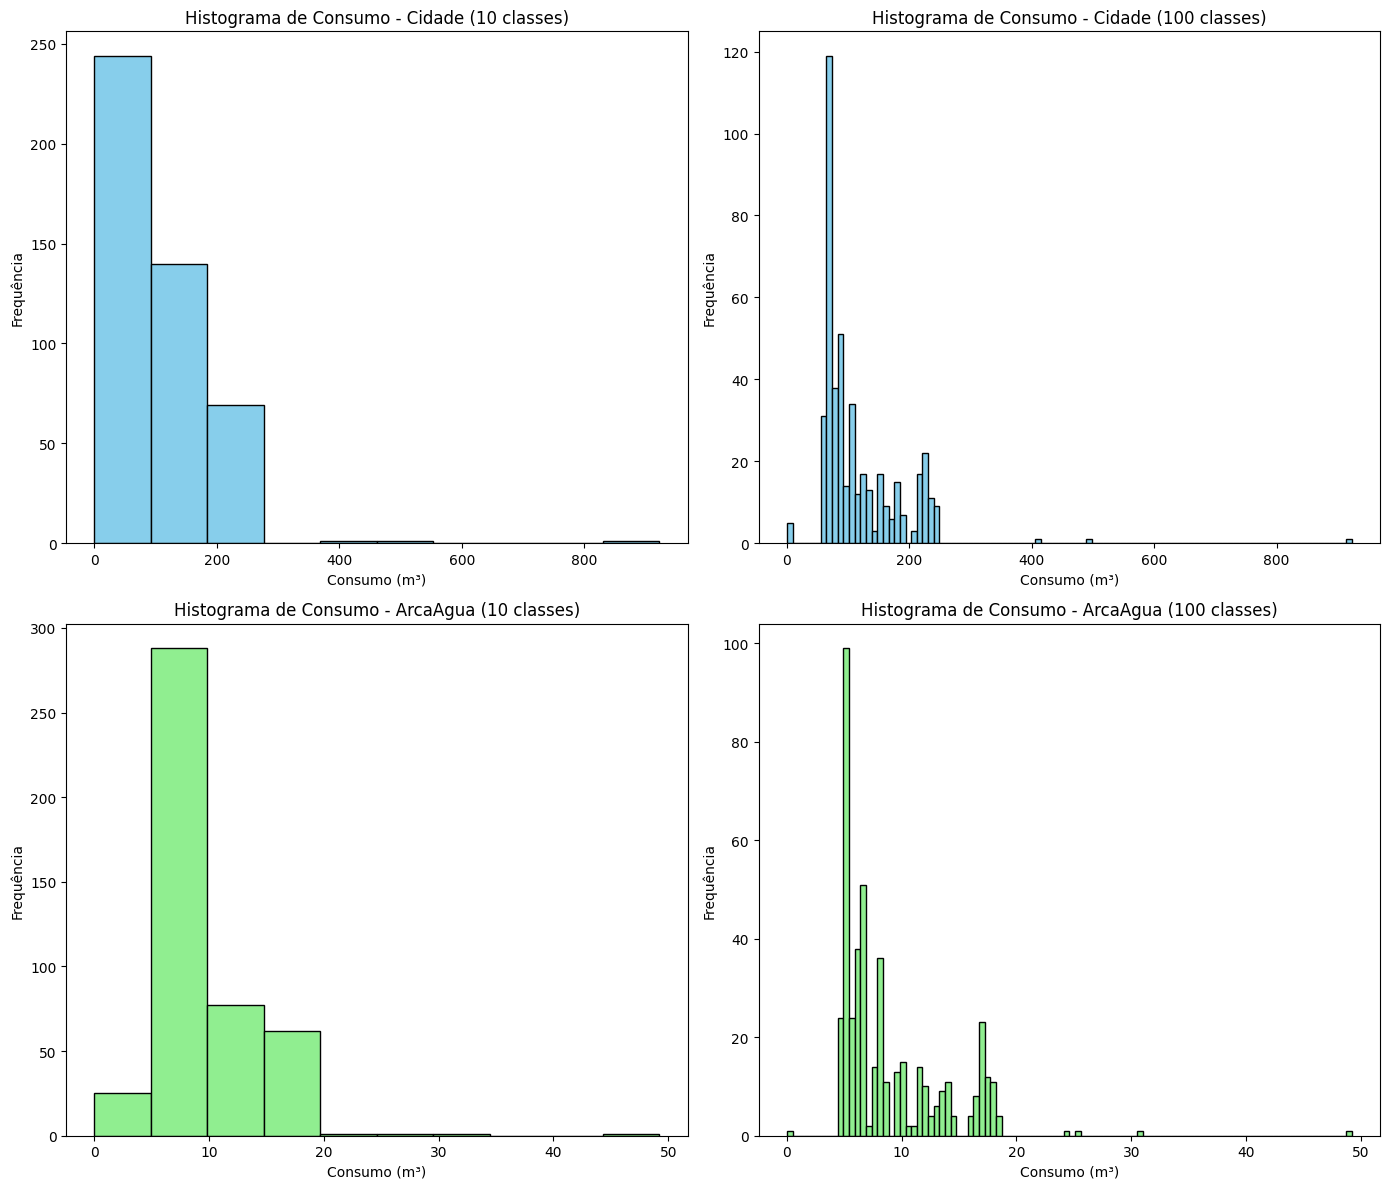

In [12]:
# Criar histogramas
plt.figure(figsize=(14, 12))

# Histograma para o parque com maior consumo com 10 classes
plt.subplot(2, 2, 1)
plt.hist(water_data[water_data['Park'] == top_park]['Consumption'].dropna(), bins=10, color='skyblue', edgecolor='black')
plt.title(f'Histograma de Consumo - {top_park} (10 classes)')
plt.xlabel('Consumo (m³)')
plt.ylabel('Frequência')

# Histograma para o parque com maior consumo com 100 classes
plt.subplot(2, 2, 2)
plt.hist(water_data[water_data['Park'] == top_park]['Consumption'].dropna(), bins=100, color='skyblue', edgecolor='black')
plt.title(f'Histograma de Consumo - {top_park} (100 classes)')
plt.xlabel('Consumo (m³)')
plt.ylabel('Frequência')

# Histograma para o parque com menor consumo com 10 classes
plt.subplot(2, 2, 3)
plt.hist(water_data[water_data['Park'] == bottom_park]['Consumption'].dropna(), bins=10, color='lightgreen', edgecolor='black')
plt.title(f'Histograma de Consumo - {bottom_park} (10 classes)')
plt.xlabel('Consumo (m³)')
plt.ylabel('Frequência')

# Histograma para o parque com menor consumo com 100 classes
plt.subplot(2, 2, 4)
plt.hist(water_data[water_data['Park'] == bottom_park]['Consumption'].dropna(), bins=100, color='lightgreen', edgecolor='black')
plt.title(f'Histograma de Consumo - {bottom_park} (100 classes)')
plt.xlabel('Consumo (m³)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()


## Análise dos Histogramas de Consumo de Água nos Parques Cidade e ArcaAgua

### Parque Cidade
- **Histograma com 10 Classes:** A maioria dos consumos está concentrada na faixa até 200 m³, com uma frequência muito alta para consumos menores que 100 m³, e uma redução gradual para consumos maiores.
- **Histograma com 100 Classes:** Oferece uma visão mais detalhada da distribuição, evidenciando a concentração de dias com consumos entre 50 m³ e 150 m³. Existem picos específicos dentro desta faixa, sugerindo padrões regulares de consumo elevado.

### Análise do Parque Cidade
O consumo no Parque Cidade é caracteristicamente variado, com a maior parte dos consumos situando-se em níveis moderados, mas com ocorrências frequentes de consumos relativamente altos. A presença de classes com consumos superiores a 600 m³, embora menos frequentes, indica dias atípicos com demandas de água muito superiores ao normal, possivelmente devido a eventos ou atividades específicas que exigem um grande volume de recursos hídricos.

### Parque ArcaAgua
- **Histograma com 10 Classes:** Mostra uma concentração esmagadora dos consumos abaixo de 10 m³, com uma queda acentuada para consumos maiores.
- **Histograma com 100 Classes:** Aprecia-se a consistência deste padrão, com a maioria esmagadora dos consumos muito abaixo de 20 m³, e poucas ocorrências acima deste valor.

### Análise do Parque ArcaAgua
O Parque ArcaAgua demonstra um padrão de consumo extremamente estável e baixo, com a maior parte dos dias apresentando consumos mínimos. O gráfico com 100 classes ajuda a entender que, mesmo dentro de um regime de baixo consumo, existem variações sutis que são importantes para o manejo eficaz dos recursos hídricos.